1. Imports

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

from src.models.train import load_data, split_data, train_all
from src.models.evaluate import evaluate_model, plot_confusion_matrix, compare_models

2. Load Data & Split

In [2]:
X, y = load_data()
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

Loaded: C:\Users\dell\food-outbreak-severity-ml\data\processed\outbreaks_featured.csv  →  X(18745, 13)  y(18745,)
Class distribution:
Severity_code
0    9823
1    6128
2    2794

Train (13121 rows) — Low:52.4%  Mod:32.7%  High:14.9%
Val (2812 rows) — Low:52.4%  Mod:32.7%  High:14.9%
Test (2812 rows) — Low:52.4%  Mod:32.7%  High:14.9%


3. Train All Models

In [3]:
trained_models = train_all(X_train, y_train, use_smote=True, save_models=True)


Training LogisticRegression...


  File "C:\Users\dell\food-outbreak-severity-ml\venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


  Saved → models\LogisticRegression.joblib

Training RandomForest...
  Saved → models\RandomForest.joblib

Training XGBoost...
  Saved → models\XGBoost.joblib

Training LightGBM...
  Saved → models\LightGBM.joblib

All models trained. Files in 'models/'


4. Evaluate on Validation Set


  LogisticRegression  [Validation]
  Macro F1 : 0.5495

              precision    recall  f1-score   support

         Low       0.77      0.72      0.74      1474
    Moderate       0.50      0.42      0.45       919
        High       0.37      0.58      0.45       419

    accuracy                           0.60      2812
   macro avg       0.54      0.57      0.55      2812
weighted avg       0.62      0.60      0.60      2812



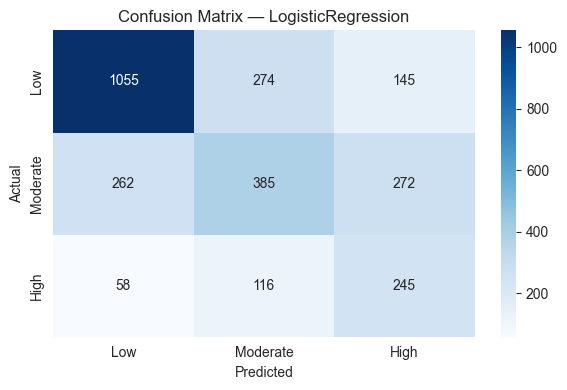


  RandomForest  [Validation]
  Macro F1 : 0.5356

              precision    recall  f1-score   support

         Low       0.73      0.76      0.75      1474
    Moderate       0.49      0.48      0.48       919
        High       0.40      0.36      0.38       419

    accuracy                           0.61      2812
   macro avg       0.54      0.53      0.54      2812
weighted avg       0.60      0.61      0.61      2812



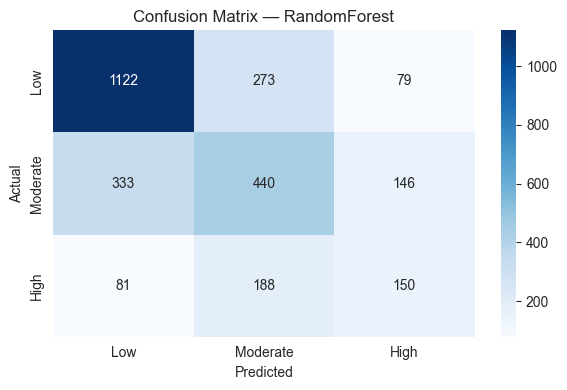


  XGBoost  [Validation]
  Macro F1 : 0.5657

              precision    recall  f1-score   support

         Low       0.74      0.80      0.77      1474
    Moderate       0.50      0.49      0.50       919
        High       0.50      0.39      0.43       419

    accuracy                           0.64      2812
   macro avg       0.58      0.56      0.57      2812
weighted avg       0.63      0.64      0.63      2812



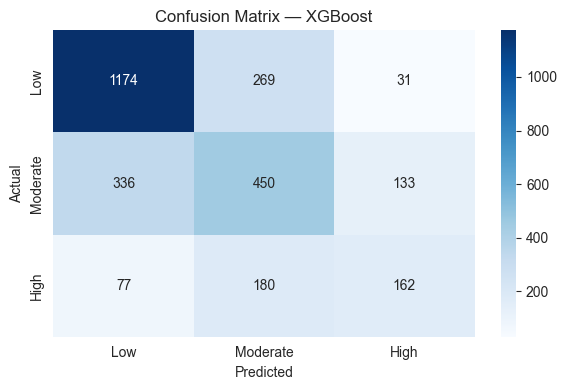


  LightGBM  [Validation]
  Macro F1 : 0.5734

              precision    recall  f1-score   support

         Low       0.75      0.79      0.77      1474
    Moderate       0.51      0.52      0.52       919
        High       0.50      0.38      0.43       419

    accuracy                           0.64      2812
   macro avg       0.59      0.56      0.57      2812
weighted avg       0.64      0.64      0.64      2812



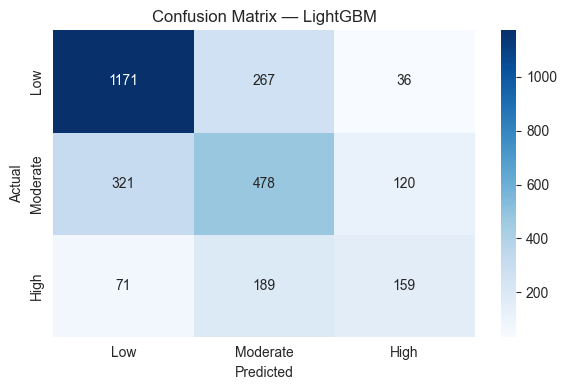

In [4]:
val_scores = {}

for name, pipeline in trained_models.items():
    macro_f1, y_pred = evaluate_model(pipeline, X_val, y_val, model_name=name)
    plot_confusion_matrix(y_val, y_pred, model_name=name)
    val_scores[name] = macro_f1

5. Compare Models & Pick Best

In [5]:
best_model_name = compare_models(val_scores)
best_model = trained_models[best_model_name]


  MODEL COMPARISON (Val Macro F1)
  1. LightGBM               0.5734  ◀ BEST
  2. XGBoost                0.5657
  3. LogisticRegression     0.5495
  4. RandomForest           0.5356


6. Final Test Set Evaluation


  LightGBM  [TEST SET]
  Macro F1 : 0.5544

              precision    recall  f1-score   support

         Low       0.74      0.79      0.76      1474
    Moderate       0.50      0.51      0.50       919
        High       0.47      0.34      0.40       419

    accuracy                           0.63      2812
   macro avg       0.57      0.55      0.55      2812
weighted avg       0.62      0.63      0.62      2812



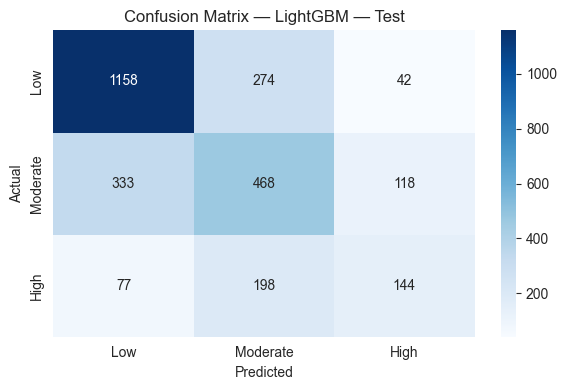

In [6]:
final_f1, y_test_pred = evaluate_model(
    best_model, X_test, y_test,
    model_name=best_model_name,
    dataset_label="TEST SET"
)
plot_confusion_matrix(y_test, y_test_pred, model_name=f"{best_model_name} — Test")

7. Save Results Summary

In [7]:
import os
os.makedirs("../results", exist_ok=True)

results_df = __import__('pandas').DataFrame({
    "Model": list(val_scores.keys()),
    "Val_Macro_F1": list(val_scores.values()),
}).sort_values("Val_Macro_F1", ascending=False).reset_index(drop=True)

results_df.to_csv("../results/model_comparison.csv", index=False)
print(results_df.to_string(index=False))
print(f"\nSaved → results/model_comparison.csv")
print(f"Best model: {best_model_name} | Test Macro F1: {final_f1:.4f}")
print(f"Saved model: models/{best_model_name}.joblib")

             Model  Val_Macro_F1
          LightGBM      0.573439
           XGBoost      0.565673
LogisticRegression      0.549480
      RandomForest      0.535622

Saved → results/model_comparison.csv
Best model: LightGBM | Test Macro F1: 0.5544
Saved model: models/LightGBM.joblib
